# Student Information


full name - Aditya Tribhuvan

Student ID - 2128382

Module name - AI Programming

Assignment Title - Dubai Real Estate Sales Insights

# 1.Introduction:

The dataset is a property listing for sales across Dubai. There are key variables like House Type, no.of Beds and Bathroom. This is a perfect supervised learning focussing on predicting the real estate market behaviour.

The UAE's property Market is one of the fastest growing, at the same time most dynamic in the world, because of it's safety, rapid development, foreign investments and shifting economic conditions. By analysing this dataset, it can give us a clear idea about how different property features can relate to market values and build predictive models that can help in predicting prices.

I selected this dataset because real-estate is a major force in the UAE's market and it also influences the economy and understanding price patterns is particularly interesting in terms of analytics. This problem is crucial for buyers,sellers,investors who focusses on data-driven insights to make informed decisions. For this project, this dataset is meaningful,rich and highly realistic while offering a meaningful challenge for data cleaning,exploration,analysis and modelling.

# 2.Data Source and Inspiration

I have collected this dataset from **Kaggle**. It is a commonly used public data platform where it is widely used for data analytics, machine learning and other data related problems. I downloaded this data on 2nd of April 2026 it was in comma separated Values(CSV) format. The dataset contains information of property listings in Dubai with features like price,area,no.of bathrooms and bedrooms.(Saleem, 2024)

I have collected this dataset from kaggle. It is a commonly used public data platform where it is widely used for data analytics, machine learning and other data related problems. I downloaded this data on 2nd of April 2026 it was in comma separated Values(CSV) format. The dataset contains information of property listings in UAE cities like Dubai,Abu Dhabi and Al-Ain with features like price,area,no.of bathrooms and bedrooms.

The dataset was downloaded because Kaggle is such a platform that public data is **readily available** for research and education purposes. The datasets in this platform **license permit academic use**,making it **ethically and legally** usable for coursework. It is common that alot of datas will have missing entries, inconsistent formatting or duplicate records. These issues will be addressed during the data cleaning process.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
url = "https://raw.githubusercontent.com/DataScientist64/DataAnalysis/main/bayut_selling_properties.csv"
df = pd.read_csv(url)
df.head(5)

,price,price_category,type,beds,baths,address,furnishing,completion_status,post_date,average_rent,...,total_parking_spaces,total_floors,total_building_area_sqft,elevators,area_name,city,country,Latitude,Longitude,purpose
0,1450000,Medium,Apartment,1,2,"The Bay, Business Bay, Dubai",Furnished,Ready,2024-04-15,0,...,0,0,0,0,Business Bay,Dubai,UAE,25.189427,55.264819,For Sale
1,6600000,High,Townhouse,5,5,"Brookfield, DAMAC Hills, Dubai",Unfurnished,Ready,2024-04-15,0,...,0,0,0,0,DAMAC Hills,Dubai,UAE,25.028148,55.264246,For Sale
2,4825000,High,Apartment,2,3,"Vida Residence Downtown, Downtown Dubai, Dubai",Unfurnished,Ready,2024-04-18,288929,...,510,56,1,11,Downtown Dubai,Dubai,UAE,25.186684,55.274705,For Sale
3,980000,Average,Apartment,3,3,"Building 39, Al Reef Downtown, Al Reef, Abu Dhabi",Unfurnished,Ready,2024-01-03,73384,...,0,0,0,0,Al Reef,Abu Dhabi,UAE,24.466437,54.656891,For Sale
4,2499999,Medium,Townhouse,3,4,"Nima, The Valley, Dubai",Furnished,Off-Plan,2024-02-28,0,...,0,0,0,0,The Valley,Dubai,UAE,25.019221,55.447201,For Sale


The dataset has been loaded from a raw Github public link which ensures reproducibility. The first few rows show property listing with features like price,price_category, bed,baths, house type.


# 3.Prediction Task

The target variable in this dataset is property sale **Price** and this is a classic example of regression. The goal is to predict the price of a property based on its features like area, no.of beds and bathrooms. This prediction task is meaningful because investors,buyers or sellers would get accurate price estimations in making informed financial decisions. At the same time, it also provides insights into the UAE market behaviour making it practically valuable and analytically interesting.

# 4.Data Cleaning and Preprocessing

Data cleaning is the process of finding and correcting errors from a particular dataset and working on data inconsistencies in raw data sets in order to improve data quality. (Rogers & Jonker, 2026).

### 4.1 Missing values

Before cleaning the dataset, each column has some missing values that can affect the models peformance and it can require imputation or removal depends on the context

In [ ]:
df.isnull().sum()

,0
price,0
price_category,0
type,0
beds,0
baths,0
address,0
furnishing,0
completion_status,0
post_date,0
average_rent,0


Only the Latitude and Longitude columns have missing columns. These features capture accurate geographical locations, rather than imputing, these rows can be removed.

In [ ]:
df = df.dropna(subset=['Latitude','Longitude'])
df.isnull().sum()

,0
price,0
price_category,0
type,0
beds,0
baths,0
address,0
furnishing,0
completion_status,0
post_date,0
average_rent,0


After removing the null values, the Latitude and Longitude columns do not have any missing values is ready for furthur cleaning steps.

## 4.2. Duplicate Rows

Duplicate rows can occur as the same property listing is posted multiple times. This can lead to biasness in the model because multiple entries can artificially increase the importance of certain properties. Hence,checking and removing duplicate rows is important.

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

There are no duplicate rows. No furthur action is required in this step.

## 4.3. Invalid or Inconsistent Values

Even though there are no missing values, some entries maybe incorrect and it must be handled to avoid problems while modelling.

In [ ]:
print("Price <=0:",(df['price'] <= 0).sum())
print("Bed <=0:",(df['beds'] <= 0).sum())
print("Bathroom <=0:",(df['baths'] <= 0).sum())
print("Rent <=0:",(df['average_rent'] <=0).sum())
print("Total floor <= 0:",(df['total_floors'] <=0).sum())
print("Area <=0:", (df['total_building_area_sqft'] <= 0).sum())
print("Parking <=0:", (df['total_parking_spaces'] <= 0).sum())

Price <=0: 16
Bed <=0: 4626
Bathroom <=0: 130
Rent <=0: 20748
Total floor <= 0: 23474
Area <=0: 23591
Parking <=0: 28348


In [ ]:
df[df['year_of_completion'] > 2025]

,price,price_category,type,beds,baths,address,furnishing,completion_status,post_date,average_rent,...,total_parking_spaces,total_floors,total_building_area_sqft,elevators,area_name,city,country,Latitude,Longitude,purpose


In [ ]:
df[(df['Latitude'] < -90) | (df['Latitude'] > 90)]
df[(df['Longitude'] < -180) | (df['Longitude'] > 180)]

,price,price_category,type,beds,baths,address,furnishing,completion_status,post_date,average_rent,...,total_parking_spaces,total_floors,total_building_area_sqft,elevators,area_name,city,country,Latitude,Longitude,purpose


Several numerical columns contain impossible values such as zero or negative prices, areas, bathrooms, and floors. These values are not realistic for property listings and must be removed. Some columns (e.g., beds, parking, rent) may legitimately contain zeros, so only negative values are removed for those cases.

In [ ]:
df = df[df['price'] > 0]
df = df[df['beds'] >= 0]
df = df[df['baths'] >= 0]
df = df[df['total_building_area_sqft'] > 0]
df = df[df['total_parking_spaces'] > 0]
df = df[df['average_rent'] > 0]
df = df[df['total_floors'] > 0]

In [ ]:
df.head(5)

,price,price_category,type,beds,baths,address,furnishing,completion_status,post_date,average_rent,...,total_parking_spaces,total_floors,total_building_area_sqft,elevators,area_name,city,country,Latitude,Longitude,purpose
2,4825000,High,Apartment,2,3,"Vida Residence Downtown, Downtown Dubai, Dubai",Unfurnished,Ready,2024-04-18,288929,...,510,56,1,11,Downtown Dubai,Dubai,UAE,25.186684,55.274705,For Sale
5,1150000,Average,Apartment,0,1,"The Sterling East, The Sterling, Business Bay,...",Unfurnished,Ready,2024-02-02,82271,...,259,27,502,6,Business Bay,Dubai,UAE,25.189427,55.264819,For Sale
12,2750000,Medium,Apartment,1,1,"Lamtara Building 3, Lamtara, Madinat Jumeirah ...",Furnished,Ready,2024-01-22,135475,...,138,9,298,2,Umm Suqeim,Dubai,UAE,25.164759,55.218728,For Sale
1012,1100000,Average,Apartment,1,2,"Binghatti Gateway, Al Jaddaf, Dubai",Unfurnished,Ready,2024-04-02,96107,...,271,19,401,4,Al Jaddaf,Dubai,UAE,25.214294,55.324569,For Sale
1017,1200000,Average,Apartment,1,2,"Signature Livings North, Signature Livings, JV...",Furnished,Ready,2024-01-17,79226,...,146,6,186,2,Jumeirah Village Circle (JVC),Dubai,UAE,25.055945,55.207465,For Sale


All the numerical columns have been changed into a consistent format and this will futhur help in our model building.

## 4.4 Data types

Another important aspect is checking the data types of a column whether a numerical column is an integer or a float. Date column is in the datetime format and categorical/name variables are stored as objects. If this is not checked and its incorrect, it can affect the pre-processing and model training.

In [ ]:
df.dtypes

,0
price,int64
price_category,object
type,object
beds,int64
baths,int64
address,object
furnishing,object
completion_status,object
post_date,object
average_rent,int64


Some columns in the dataset like post-date is in an object form. But in reality it should be in a date format. Converting these appropriate types will ensure correct pre-processing while modelling

In [ ]:
df['post_date'] = pd.to_datetime(df['post_date'], errors='coerce')

In [ ]:
categorical_cols = ['price_category','type','address','furnishing',
                    'completion_status','building_name','area_name',
                    'city','country','purpose']

In [ ]:
for col in categorical_cols:
  df[col] = df[col].astype('category')

In [ ]:
df.dtypes

,0
price,int64
price_category,category
type,category
beds,int64
baths,int64
address,category
furnishing,category
completion_status,category
post_date,datetime64[ns]
average_rent,int64


In [ ]:
df.head(5)

,price,price_category,type,beds,baths,address,furnishing,completion_status,post_date,average_rent,...,total_parking_spaces,total_floors,total_building_area_sqft,elevators,area_name,city,country,Latitude,Longitude,purpose
2,4825000,High,Apartment,2,3,"Vida Residence Downtown, Downtown Dubai, Dubai",Unfurnished,Ready,2024-04-18,288929,...,510,56,1,11,Downtown Dubai,Dubai,UAE,25.186684,55.274705,For Sale
5,1150000,Average,Apartment,0,1,"The Sterling East, The Sterling, Business Bay,...",Unfurnished,Ready,2024-02-02,82271,...,259,27,502,6,Business Bay,Dubai,UAE,25.189427,55.264819,For Sale
12,2750000,Medium,Apartment,1,1,"Lamtara Building 3, Lamtara, Madinat Jumeirah ...",Furnished,Ready,2024-01-22,135475,...,138,9,298,2,Umm Suqeim,Dubai,UAE,25.164759,55.218728,For Sale
1012,1100000,Average,Apartment,1,2,"Binghatti Gateway, Al Jaddaf, Dubai",Unfurnished,Ready,2024-04-02,96107,...,271,19,401,4,Al Jaddaf,Dubai,UAE,25.214294,55.324569,For Sale
1017,1200000,Average,Apartment,1,2,"Signature Livings North, Signature Livings, JV...",Furnished,Ready,2024-01-17,79226,...,146,6,186,2,Jumeirah Village Circle (JVC),Dubai,UAE,25.055945,55.207465,For Sale


After performing the required data type conversions like converting data type to categories and post-date from object to datetime and the numerical columns in integer or float format, this ensure smooth encoding,scaling and model training.

## 4.5 Feature selection

feature selection is the process of taking relevant features for a machine learning model which helps in model performance,reduction in the noise and allowing results to be easier for understanding.Another use of it is improving accuracy and reduces overfitting.(Geeks, 2025).

In [ ]:
cols_to_drop = ['price_category','address','building_name','country','post_date','city']
df = df.drop(columns=cols_to_drop)

In [ ]:
df.head(5)

,price,type,beds,baths,furnishing,completion_status,average_rent,year_of_completion,total_parking_spaces,total_floors,total_building_area_sqft,elevators,area_name,Latitude,Longitude,purpose
2,4825000,Apartment,2,3,Unfurnished,Ready,288929,2018,510,56,1,11,Downtown Dubai,25.186684,55.274705,For Sale
5,1150000,Apartment,0,1,Unfurnished,Ready,82271,2023,259,27,502,6,Business Bay,25.189427,55.264819,For Sale
12,2750000,Apartment,1,1,Furnished,Ready,135475,2021,138,9,298,2,Umm Suqeim,25.164759,55.218728,For Sale
1012,1100000,Apartment,1,2,Unfurnished,Ready,96107,2021,271,19,401,4,Al Jaddaf,25.214294,55.324569,For Sale
1017,1200000,Apartment,1,2,Furnished,Ready,79226,2021,146,6,186,2,Jumeirah Village Circle (JVC),25.055945,55.207465,For Sale


After removing features like price category,city,country, the dataset now contains meaningful features and model friendly features. Along with that redundant columns are removed and data leakage is blocked.

## 4.6 Encoding Variables

Encoding is the process where categorical variables are converted into numerical ones for machine learning models because in such models, they don't understand data in character or object form. In this dataset one hot encoding. It is when a binary column is created for each category and returns a sparse matrix.(DelSole, 2018).

In [ ]:
df_encoded = pd.get_dummies(df,columns=['type', 'furnishing', 'completion_status',
                                     'area_name', 'purpose'],drop_first=True)

Drop_first is used to keep the model stable and reduce the number of dummy variables.

In [ ]:
df_encoded.dtypes

,0
price,int64
beds,int64
baths,int64
average_rent,int64
year_of_completion,int64
...,...
area_name_Town Square,bool
area_name_Umm Suqeim,bool
area_name_Wasl Gate,bool
area_name_World Trade Centre,bool


In [ ]:
df_encoded.head(5)

,price,beds,baths,average_rent,year_of_completion,total_parking_spaces,total_floors,total_building_area_sqft,elevators,Latitude,...,area_name_Muhaisnah,area_name_Palm Jumeirah,area_name_Remraam,area_name_Sobha Hartland,area_name_The Hills,area_name_Town Square,area_name_Umm Suqeim,area_name_Wasl Gate,area_name_World Trade Centre,area_name_Za'abeel
2,4825000,2,3,288929,2018,510,56,1,11,25.186684,...,False,False,False,False,False,False,False,False,False,False
5,1150000,0,1,82271,2023,259,27,502,6,25.189427,...,False,False,False,False,False,False,False,False,False,False
12,2750000,1,1,135475,2021,138,9,298,2,25.164759,...,False,False,False,False,False,False,True,False,False,False
1012,1100000,1,2,96107,2021,271,19,401,4,25.214294,...,False,False,False,False,False,False,False,False,False,False
1017,1200000,1,2,79226,2021,146,6,186,2,25.055945,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_encoded.columns

Index(['price', 'beds', 'baths', 'average_rent', 'year_of_completion',
       'total_parking_spaces', 'total_floors', 'total_building_area_sqft',
       'elevators', 'Latitude', 'Longitude', 'type_Hotel Apartment',
       'type_Penthouse', 'furnishing_Unfurnished', 'area_name_Al Furjan',
       'area_name_Al Jaddaf', 'area_name_Al Quoz', 'area_name_Al Sufouh',
       'area_name_Al Wasl', 'area_name_Arjan',
       'area_name_Barsha Heights (Tecom)', 'area_name_Bluewaters Island',
       'area_name_Bur Dubai', 'area_name_Business Bay',
       'area_name_Culture Village', 'area_name_DAMAC Hills',
       'area_name_DAMAC Hills 2 (Akoya by DAMAC)', 'area_name_Downtown Dubai',
       'area_name_Dubai Creek Harbour', 'area_name_Dubai Festival City',
       'area_name_Dubai Harbour', 'area_name_Dubai Hills Estate',
       'area_name_Dubai Marina', 'area_name_Dubai Maritime City',
       'area_name_Dubai Media City', 'area_name_Dubai Production City (IMPZ)',
       'area_name_Dubai Residence Co

The dataset is fully encoded

## 4.7 Feature Scaling

Feature Scaling is converting numerical features into a dataset on a common scale or range. The importance of using this technique is it can cause the model to weigh feature unequally which can lead to poor performance. Benefits of this technique is allowing the model to treat features equally, prevent biasness and improving alogrithm performance.(Singh, 2024).

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
num_cols = ['beds','baths','average_rent','year_of_completion',
            'total_parking_spaces','total_floors','total_building_area_sqft',
            'elevators','Latitude','Longitude']

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [ ]:
df_encoded.head(5)

,price,beds,baths,average_rent,year_of_completion,total_parking_spaces,total_floors,total_building_area_sqft,elevators,Latitude,...,area_name_Muhaisnah,area_name_Palm Jumeirah,area_name_Remraam,area_name_Sobha Hartland,area_name_The Hills,area_name_Town Square,area_name_Umm Suqeim,area_name_Wasl Gate,area_name_World Trade Centre,area_name_Za'abeel
2,4825000,0.619051,0.928405,0.312212,-0.021408,-0.077566,1.230793,-1.178386,0.805428,0.912108,...,False,False,False,False,False,False,False,False,False,False
5,1150000,-1.555313,-1.117003,-0.261184,0.087942,-0.659546,-0.147673,0.604971,-0.188103,0.950433,...,False,False,False,False,False,False,False,False,False,False
12,2750000,-0.468131,-1.117003,-0.113563,0.044202,-0.940102,-1.003273,-0.121186,-0.982927,0.605681,...,False,False,False,False,False,False,True,False,False,False
1012,1100000,-0.468131,-0.094299,-0.222794,0.044202,-0.631722,-0.527939,0.245452,-0.585515,1.297969,...,False,False,False,False,False,False,False,False,False,False
1017,1200000,-0.468131,-0.094299,-0.269632,0.044202,-0.921553,-1.145872,-0.519861,-0.982927,-0.915072,...,False,False,False,False,False,False,False,False,False,False


## 4.8 Train Test split

A Machine Learning technique that is used to divide data into training and testing data. This is to check how a model generalizes when new data is fed in. If a data is not split into training and testing, it won't stimulate well when new data is fed in. It will also cause overfitting on the dataset which means the model doesn't generalize well and this can lead to fitting the data very close to the training data.(Galarnyk, 2025).

The dataset is split into X and y variables. X is the independent variables and y is the target variable which is price.

In [ ]:
X = df_encoded.drop('price',axis=1)
y = df_encoded['price']

In [ ]:
print(y.head(5))

2       4825000
5       1150000
12      2750000
1012    1100000
1017    1200000
Name: price, dtype: int64


In [ ]:
print(X.head(5))

          beds     baths  average_rent  year_of_completion  \
2     0.619051  0.928405      0.312212           -0.021408   
5    -1.555313 -1.117003     -0.261184            0.087942   
12   -0.468131 -1.117003     -0.113563            0.044202   
1012 -0.468131 -0.094299     -0.222794            0.044202   
1017 -0.468131 -0.094299     -0.269632            0.044202   

      total_parking_spaces  total_floors  total_building_area_sqft  elevators  \
2                -0.077566      1.230793                 -1.178386   0.805428   
5                -0.659546     -0.147673                  0.604971  -0.188103   
12               -0.940102     -1.003273                 -0.121186  -0.982927   
1012             -0.631722     -0.527939                  0.245452  -0.585515   
1017             -0.921553     -1.145872                 -0.519861  -0.982927   

      Latitude  Longitude  ...  area_name_Muhaisnah  area_name_Palm Jumeirah  \
2     0.912108   0.506242  ...                False         

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 5.Exploratory Data Analysis

Exploratory Data Analysis is an open end iterative data analysis approach designed to find hypothesis, create visualizations,anomolies,relationships or insights with perceived notions. It is used to ensure that assumptions are met, generate hypotheses and decide the best statistical method which is appropriate for the dataset.(Coursera,2025).

**For the Real Estate Dataset, EDA will be performed and interpretations will be made**.

## 5.1  What do the variables look like?

In [ ]:
print("Shape", df.shape)

df.info()

Shape (7852, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 7852 entries, 2 to 41162
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   price                     7852 non-null   int64   
 1   type                      7852 non-null   category
 2   beds                      7852 non-null   int64   
 3   baths                     7852 non-null   int64   
 4   furnishing                7852 non-null   category
 5   completion_status         7852 non-null   category
 6   average_rent              7852 non-null   int64   
 7   year_of_completion        7852 non-null   int64   
 8   total_parking_spaces      7852 non-null   int64   
 9   total_floors              7852 non-null   int64   
 10  total_building_area_sqft  7852 non-null   int64   
 11  elevators                 7852 non-null   int64   
 12  area_name                 7852 non-null   category
 13  Latitude                  7852 non-

Overall there are 7852 rows and 16 columns in this dataset.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,7852.0,2.843953e+06,3.657860e+06,350000.000000,1000000.000000,1.850000e+06,3.300000e+06,7.200000e+07
beds,7852.0,1.430591e+00,9.198675e-01,0.000000,1.000000,1.000000e+00,2.000000e+00,4.000000e+00
baths,7852.0,2.092206e+00,9.778624e-01,1.000000,1.000000,2.000000e+00,3.000000e+00,6.000000e+00
average_rent,7852.0,1.764045e+05,3.604341e+05,25383.000000,79990.000000,1.273010e+05,2.067250e+05,2.807952e+07
year_of_completion,7852.0,2.018979e+03,4.572782e+01,0.000000,2019.000000,2.021000e+03,2.022000e+03,2.024000e+03
total_parking_spaces,7852.0,5.434530e+02,4.313135e+02,8.000000,217.000000,4.360000e+02,7.380000e+02,1.959000e+03
total_floors,7852.0,3.010672e+01,2.103922e+01,1.000000,12.000000,2.700000e+01,4.600000e+01,8.200000e+01
total_building_area_sqft,7852.0,3.320450e+02,2.809488e+02,1.000000,87.000000,2.860000e+02,5.480000e+02,9.830000e+02
elevators,7852.0,6.946638e+00,5.032877e+00,0.000000,4.000000,6.000000e+00,8.000000e+00,4.200000e+01
Latitude,7852.0,2.512142e+01,7.155727e-02,24.914439,25.055945,2.511809e+01,2.518943e+01,2.526387e+01


In [ ]:
print("Mean price: ",np.mean(df['price']).round(0))
print("Median price: ",np.median(df['price']).round(0))
print("Median price: ",np.percentile(df['price'],[5,25,50,75,95]).round(0))

Mean price:  2843953.0
Median price:  1850000.0
Median price:  [ 550000. 1000000. 1850000. 3300000. 7800000.]


The mean above is higher than the median and it shows that a right skewed distribution. While they are properties between 1-2 million, there are other luxurious properties with very high prices that has caused an overall increase in average. On the other hand, the percentile values reveal market tiers; the lower quartile sits at 1M AED, the median is at 1.85M AED, the upper quartile at 3.3M AED and the top 5% exceed at 7.8M AED. This shows that there is the presence of luxury outliers and this shows that there is a log-transformation of price, which would be beneficial for modelling.

## 5.2 How are features Distributed?

We will use it for features like:



1.   Price.
2.   Total area.
1.   Average Rent.
2.   Number of Bathrooms.
1.   Number of Bedrooms.
2.   Year of completion.







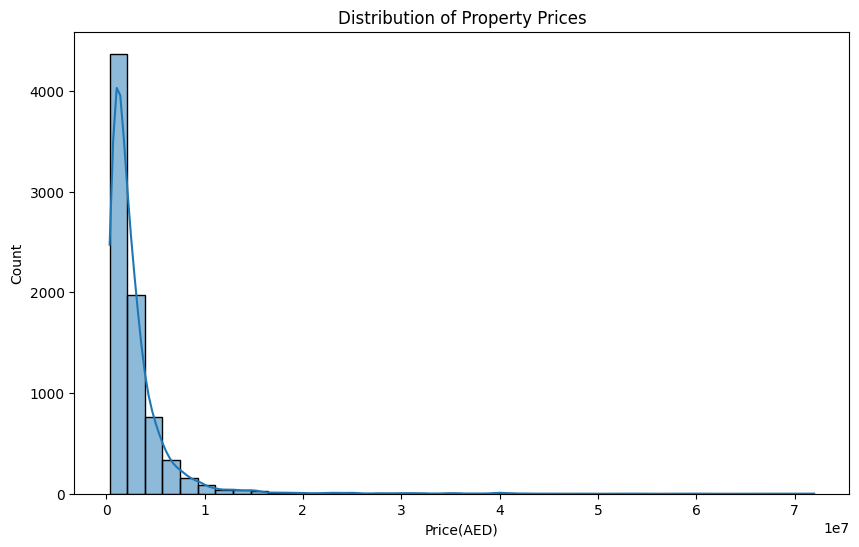

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'],kde=True,bins=40)
plt.title("Distribution of Property Prices")
plt.xlabel("Price(AED)")
plt.ylabel("Count")
plt.show()

The dataset is highly skewed as the most of the prices fall between 1-3 Million AED whereas, small number of luxury houses extends the tail to the right. This shows that the mean(2.84M) AED is more than the median (1.85M) AED. Extreme high-value properties pull the average upwards. This trend is observed in real estate market where luxury properties are rare, but significantly expensive that the standard properties.

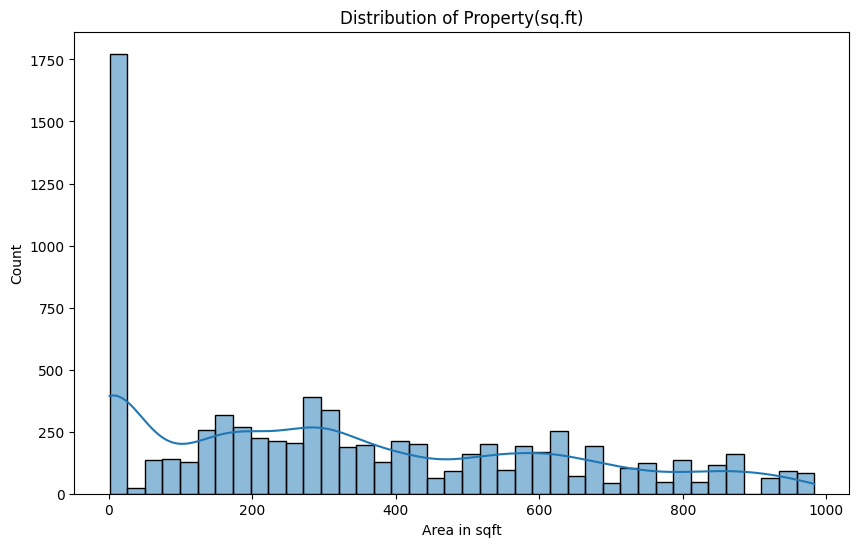

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['total_building_area_sqft'],kde=True,bins=40)
plt.title("Distribution of Property(sq.ft)")
plt.xlabel("Area in sqft")
plt.ylabel("Count")
plt.show()

In the above graph, total area is also right skewed. Most properties are between 500-2000 sq.ft while the long tail represents villa and penthouse. This kind of pattern is generally mixed in residential datasets.


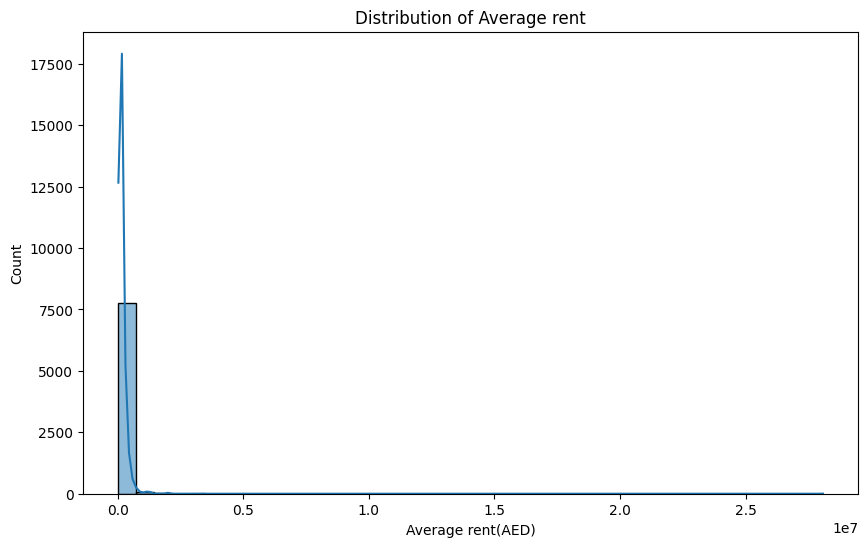

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['average_rent'],kde=True,bins=40)
plt.title("Distribution of Average rent")
plt.xlabel("Average rent(AED)")
plt.ylabel("Count")
plt.show()

Just like the property prices, average rent is also right skewed because of the strong relation between price and rent. There are several properties that fall in the lower rent range, with small number of high rent luxury units

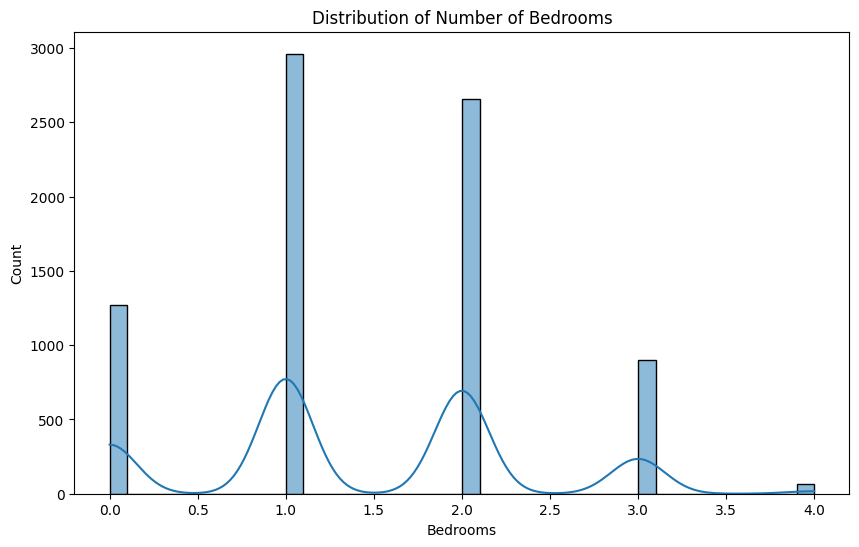

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['beds'],kde=True,bins=40)
plt.title("Distribution of Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Count")
plt.show()

There are clearly a majority of houses having bedrooms between studio-2 bedrooms. This shows that the dataset is dominated by apartments more than villas.

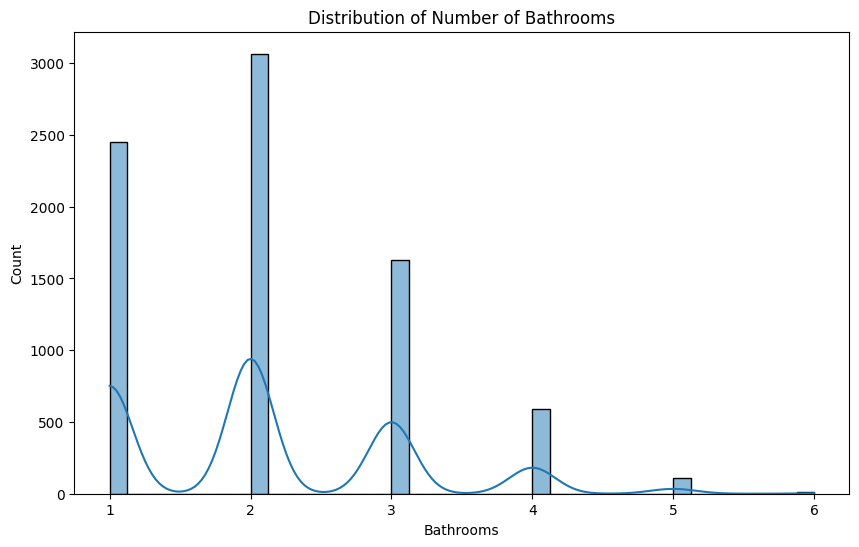

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['baths'],kde=True,bins=40)
plt.title("Distribution of Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Count")
plt.show()

The distribution is having bathrooms between 1-3. This shows that the dataset is apartment heavy.

## 5.3 Are there outliers or anomalies?

The features used are:

1.   Price.
2.   Total area.
1.   Average rent.






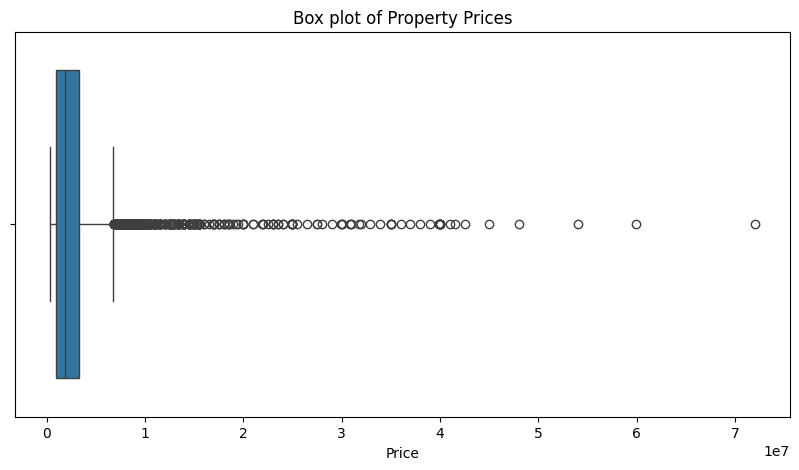

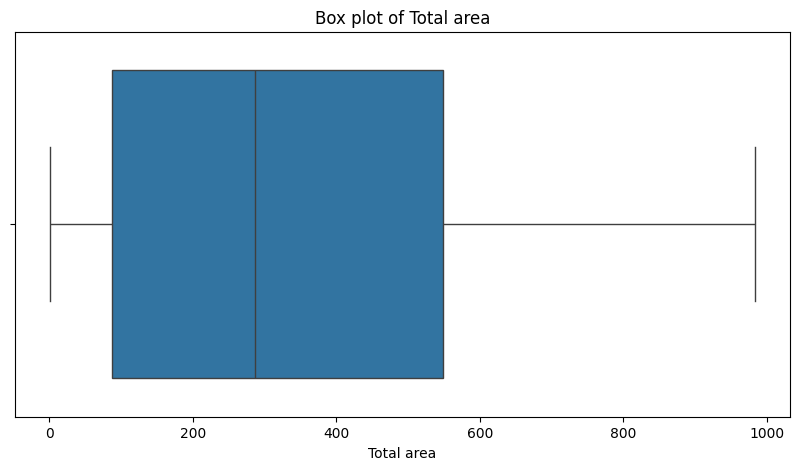

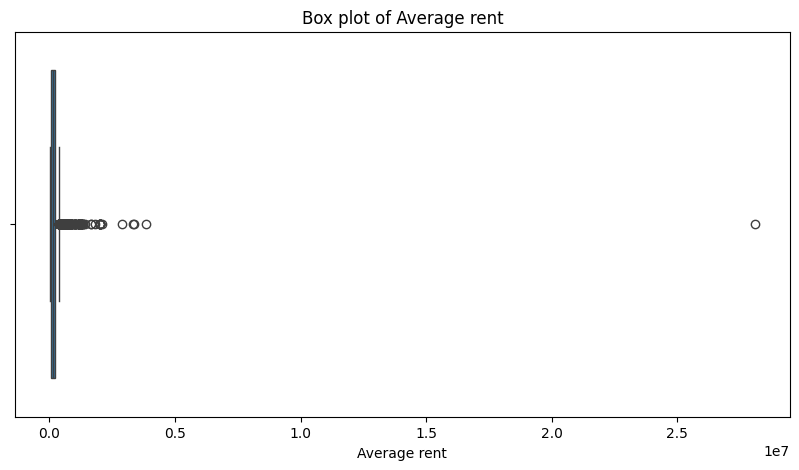

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title("Box plot of Property Prices")
plt.xlabel("Price")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=df['total_building_area_sqft'])
plt.title("Box plot of Total area")
plt.xlabel("Total area")
plt.show()


plt.figure(figsize=(10,5))
sns.boxplot(x=df['average_rent'])
plt.title("Box plot of Average rent")
plt.xlabel("Average rent")
plt.show()


Points are away from the box shows that there are potential outliers. In this case the flags above 95 percentile as the potential outliers.

In [ ]:
price_treshold = np.percentile(df['price'],95)
area_treshold = np.percentile(df['total_building_area_sqft'],95)
average_rent_treshold = np.percentile(df['average_rent'],95)


price_outliers = df[df['price'] > price_treshold]
area_outliers = df[df['total_building_area_sqft'] > price_treshold]
rent_outliers = df[df['average_rent']> price_treshold]

print(price_outliers.head(5))
print(area_outliers.head(5))
print(rent_outliers.head(5))


         price       type  beds  baths   furnishing completion_status  \
1414  16499999  Apartment     4      5    Furnished             Ready   
1424   9500000  Apartment     3      4  Unfurnished             Ready   
1574   8440000  Apartment     3      4  Unfurnished             Ready   
1579   9250000  Apartment     2      3    Furnished             Ready   
1597  18300000  Apartment     4      5  Unfurnished             Ready   

      average_rent  year_of_completion  total_parking_spaces  total_floors  \
1414        849972                2010                   469            12   
1424        688752                2021                  1495            82   
1574        525960                2022                   344            40   
1579        473254                2009                   884            65   
1597        861771                2022                   344            40   

      total_building_area_sqft  elevators                       area_name  \
1414           

Outliers was performed on price, total area and average rent and all the three showed outliers.

In **price**,a long right tail with several extreme high-value properties far above the Typical range. Whereas, the **total area** has large units, that sit beyond the upper whisker of the plot. On the other hand, the **average rent** follows the same trend, with small number of high end properties forming the upper outlier of the group.

These outliers are not errors but they represent a large segment of the luxury segement of the Dubai real estate market. But their extreme values could influence regression models. Hence, transformation like robust methods or log-price can be helpful for modelling.

## 5.4 Which features appear related to the target?

The relationship between price and other important predictors like:



1.   Total area.
2.   Beds.
1.   Baths.
2.   Average rent.





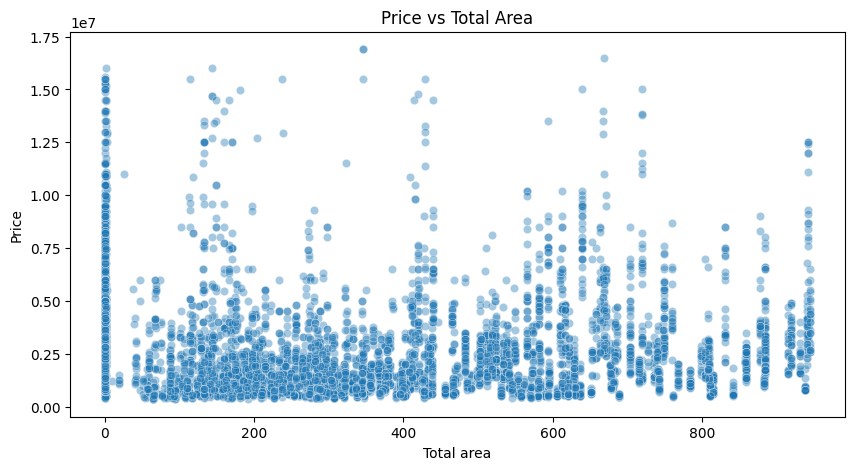

In [ ]:
df_filtered = df[
    (df['total_building_area_sqft'] < (df['total_building_area_sqft'].quantile(0.99))) &
     (df['price'] < df['price'].quantile(0.99))
]

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df_filtered['total_building_area_sqft'],
    y=df_filtered['price'],
    alpha=0.4
)


plt.title("Price vs Total Area")
plt.xlabel("Total area")
plt.ylabel("Price")

plt.show()

The above graph shows a weak relationship between total area and price, like very small areas with high prices and large areas with moderate prices. Clusters appear throughout the range, indicating that area alone doesn't explain the price

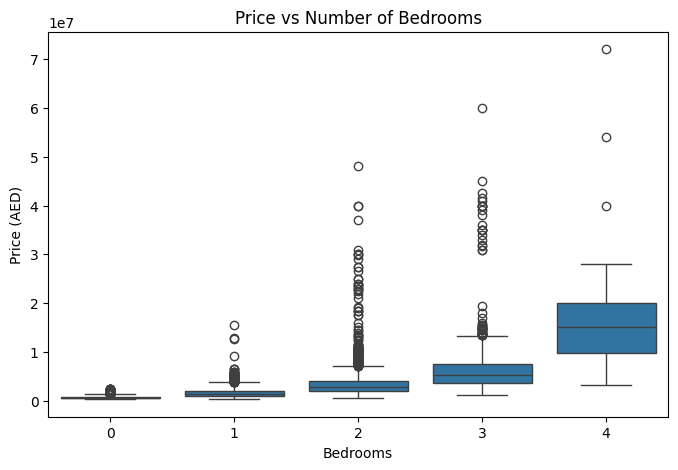

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['beds'], y=df['price'])
plt.title("Price vs Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price (AED)")
plt.show()

The prices increases when the number of bedrooms increases. The median increases steadily from 1 to 4 bedrooms.

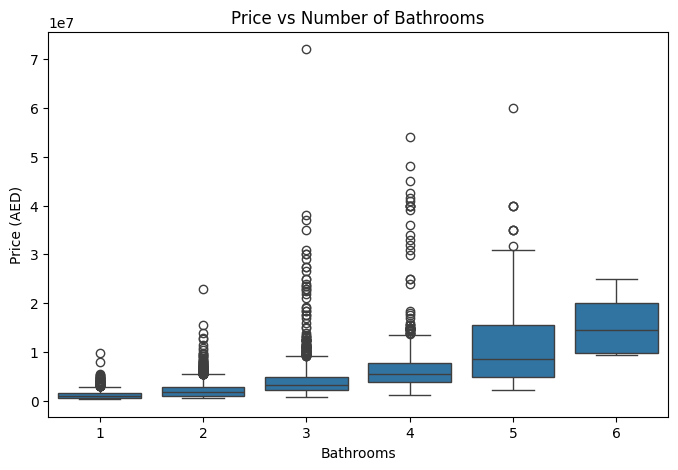

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['baths'], y=df['price'])
plt.title("Price vs Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price (AED)")
plt.show()

The same trend is shown with bathrooms. More bathrooms are associated with higher prices. This shows the typical structure of high end properties.

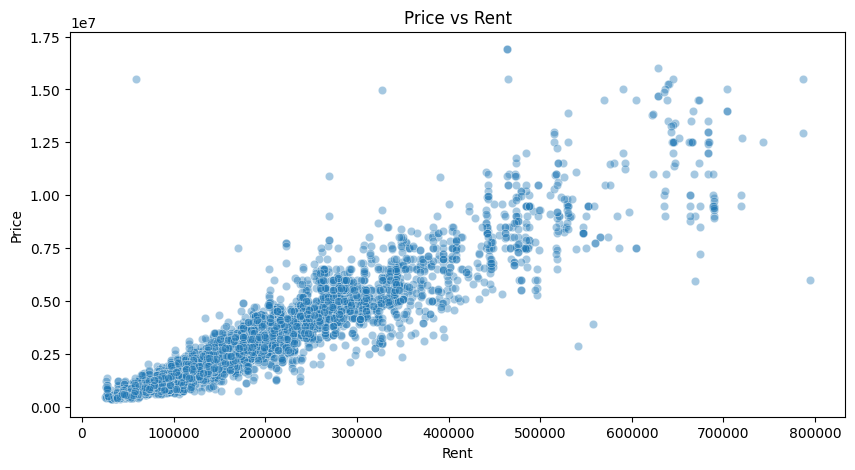

In [ ]:
df_filtered = df[
    (df['average_rent'] < df['average_rent'].quantile(0.99)) &
    (df['price'] < df['price'].quantile(0.99))
]

plt.figure(figsize=(10,5))

sns.scatterplot(
    x=df_filtered['average_rent'],
    y=df_filtered['price'],
    alpha=0.4
)


plt.title("Price vs Rent")
plt.xlabel("Rent")
plt.ylabel("Price")

plt.show()

The shows a strong relationship between price and rent. As price increases, rent also increases in a fairly consistent pattern.

**In the price vs total area and average rent, the quantile 99% was used in order to remove extreme outliers so that the visualization reflect the general trend of the data without being interupted by high values.**

## 5.5 is the dataset imbalanced?

Imbalance is checked on categorical variables like:

1.   Purpose.
1.   Property type.
2.   Furnishing.





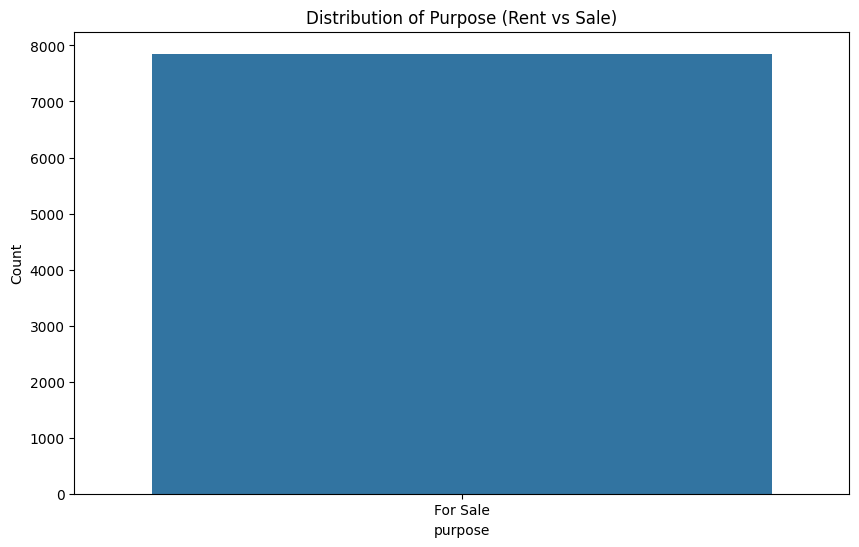

,proportion
purpose,
For Sale,1.0


In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['purpose'])
plt.title("Distribution of Purpose (Rent vs Sale)")
plt.xlabel("purpose")
plt.ylabel("Count")
plt.show()

df['purpose'].value_counts(normalize=True)

Even though there is one category, it is still imbalanced, which results in zero variance. Other than that, there is no other category. Since this feature provides no information for modelling, it will be removed from the dataset.

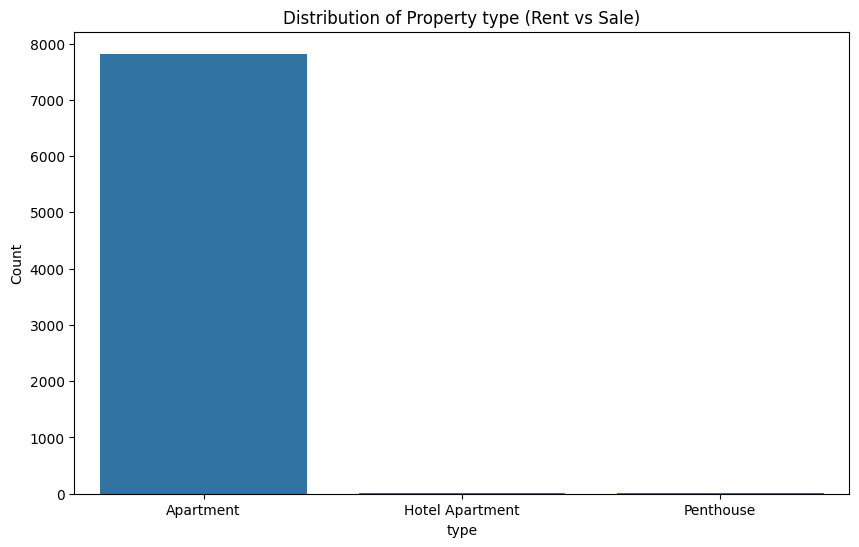

,proportion
type,
Apartment,0.995797
Hotel Apartment,0.002547
Penthouse,0.001656


In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['type'])
plt.title("Distribution of Property type (Rent vs Sale)")
plt.xlabel("type")
plt.ylabel("Count")
plt.show()

df['type'].value_counts(normalize=True)

The feature has a highly imbalanced dataset. This means that minority categories provide limited information while modelling and may not be learned effectively by predictive algorithms. This feature would either require grouping or simplification.

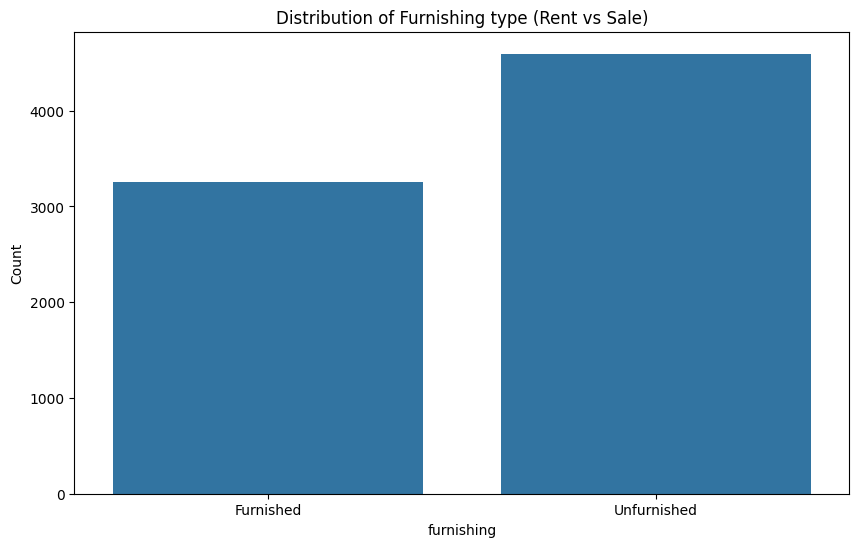

,proportion
furnishing,
Unfurnished,0.585201
Furnished,0.414799


In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x=df['furnishing'])
plt.title("Distribution of Furnishing type (Rent vs Sale)")
plt.xlabel("furnishing")
plt.ylabel("Count")
plt.show()

df['furnishing'].value_counts(normalize=True)

The pattern shows a mild balance and this feature doesn't suffer from severe imbalancing and can be safely used for modelling.

## 5.6 are there patterns that may affect modelling?

The kind of relationships that will be showed are:



1.   Geography Pattern.
2.   Price Density Contour Plot.
1.   3D Plot: Areas + Bedrooms + Price.
2.   Non-linear Patterns.




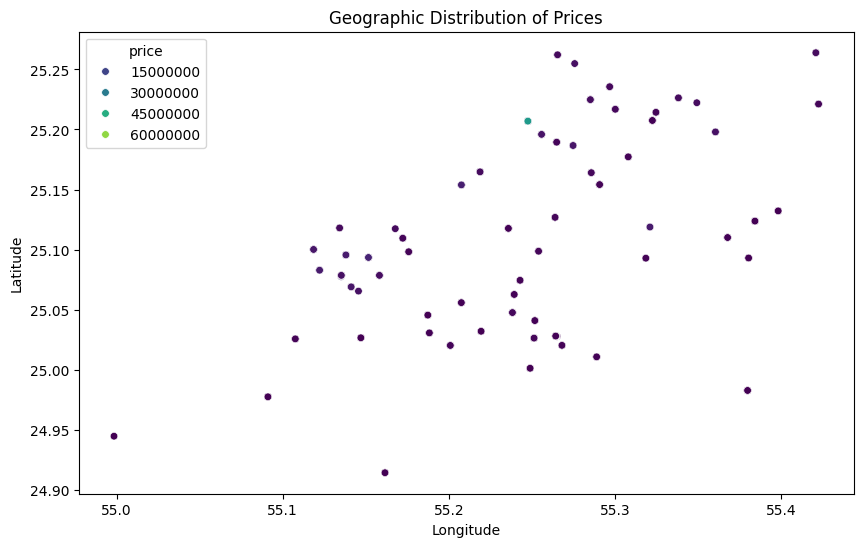

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['Longitude'],
    y=df['Latitude'],
    hue=df['price'],
    palette = 'viridis',
    s = 30
)

plt.title("Geographic Distribution of Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Prices are similar across most of the areas with just one which is at the higher end(villa or penthouse). It shows that high and low prices are distributed rather than clustered.

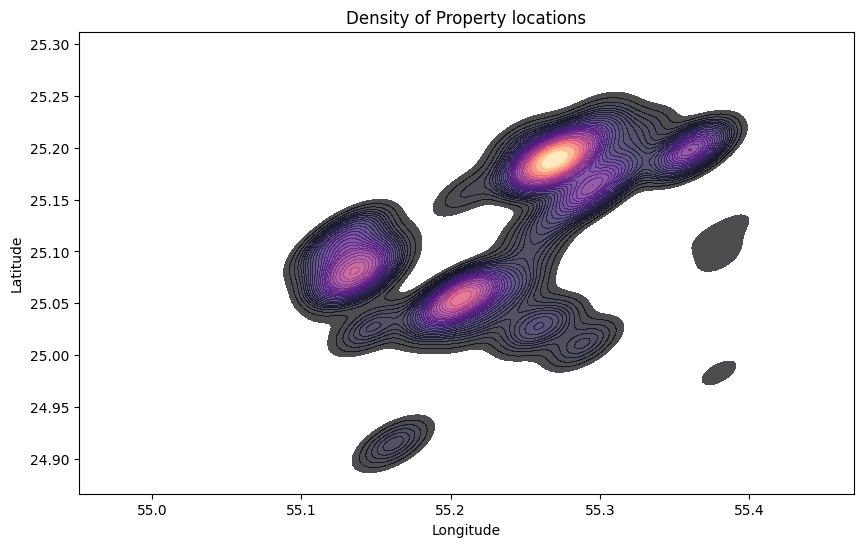

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(
    x=df['Longitude'],
    y=df['Latitude'],
    fill = True,
    cmap = 'magma',
    levels= 30,
    alpha = 0.7
)

plt.title("Density of Property locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

The contour maps shows that they are not evenly spread out, but instead clusters in few main areas. The brightest contours are the ones that mark the highest density zones, means all the property are located in the central and northeastern regions. Darker widely spaced maps shows low density areas with little properties available.

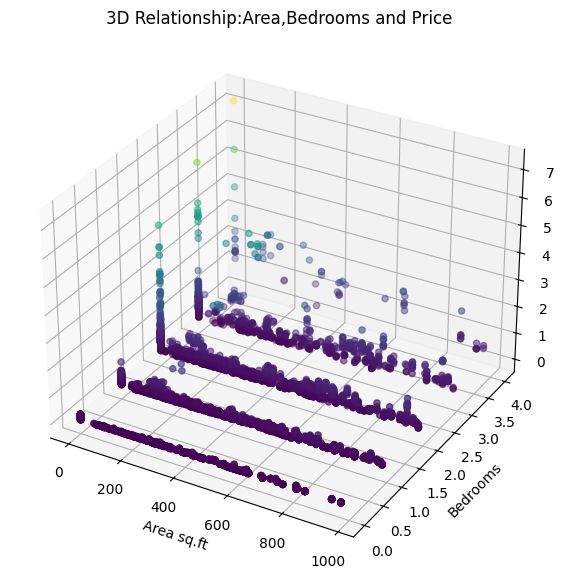

In [ ]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['total_building_area_sqft'],
    df['beds'],
    df['price'],
    c=df['price'],
    cmap='viridis',
    s=20
)

ax.set_xlabel("Area sq.ft"),
ax.set_ylabel("Bedrooms"),
ax.set_zlabel("Price in AED")
plt.title("3D Relationship:Area,Bedrooms and Price")
plt.show()

Total area doesn't get influenced by the price, but mainly with the number of bedroom. Expensive properties may have 4 bedrooms but the area is not too big.

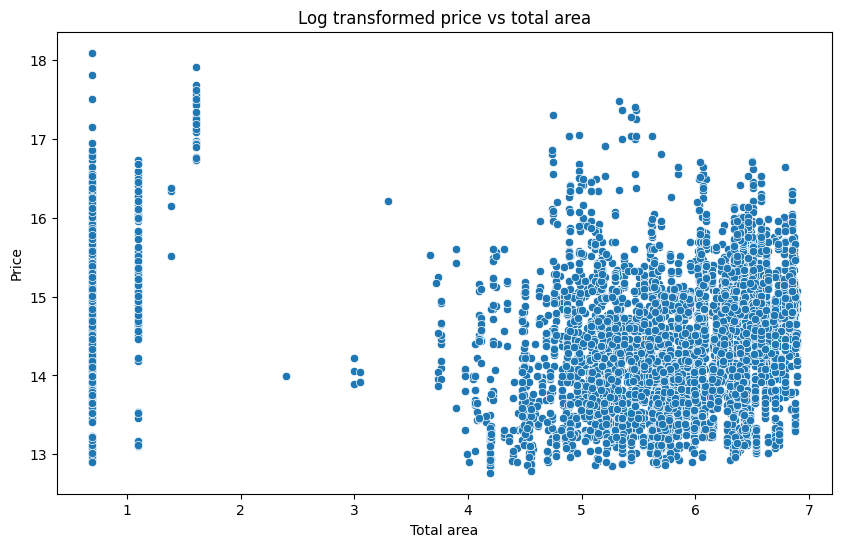

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=np.log1p(df['total_building_area_sqft']), y=np.log1p(df['price']))
plt.title("Log transformed price vs total area")
plt.xlabel("Total area")
plt.ylabel("Price")
plt.show()

Despite applying the log transformation, the relationship between price and total area is still weak. Price remains highly scattered in all area levels.

Overall, Several patterns may affect modelling. Like location shows that property is concentrated in few clusters, but the price doesn't vary much by location within the region. Area has weak relationship against price even applying log transformation. But, the number of bedrooms have a strong relationship with price but there have been instances that even if there are 4 bedrooms, the total area is small.

# 6. Modelling

Data Modelling is all about creating a coherent representation of data. The aim is to solve complex data by visually mapping how elements are related to each other so that data can be managed,analysed and understood.(Databricks,2025)

In this particular dataset, the **Linear Regression** model will be used because the aim is to predict prices or continuous variable.

Linear regression is a supervised learning algorithm that helps in modelling the relationship between the dependent variable and one or more independent variable. It predicts continous values that fits into a straight line that is best in representing data(GeeksforGeeks,2026).

It is simple to use because it simple and it assumes a simple relationship between the features and target. This is the **baseline model**.

This is suitable for datasets that have:

1.   Price prediction.
2.   Sales Forecasting.
1.   Demand Estimation.

With this retail dataset, the linear regression model will be used and evaluate the data if its performing well or not with scores like **r square, mean squared error(MSE),root mean squared error(RMSE) and mean absolute error(MAE)**.

The R2 score is a number that tells how independent variables in statistical models explains the variation in a dependent variable. It ranges from 0 to 1, where 1 indicates a perfect fit to the model of the dataset.(Fernando, 2025).

The MSE represents the **average** of the squared difference between the actual and predicted values in the dataset. It measures the **variance** of the residual.

The MAE measures the **absolute difference** between the actual and predicted values present in the dataset. Measures the **average** of the residual.

RMSE is the **square root** of the mean squared error(MSE). It measures the **standard deviation** of the residual.

(Chugh, 2020).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [ ]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6281, 68) (6281,)
(1571, 68) (1571,)


In [ ]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predict in scaled space
y_pred = baseline_model.predict(X_test)

print("=== Baseline Linear Regression ===")
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

=== Baseline Linear Regression ===
R² Score: -13.685696190077026
MSE: 139368176750377.61
RMSE: 11805429.968890486
MAE: 889992.8553649313


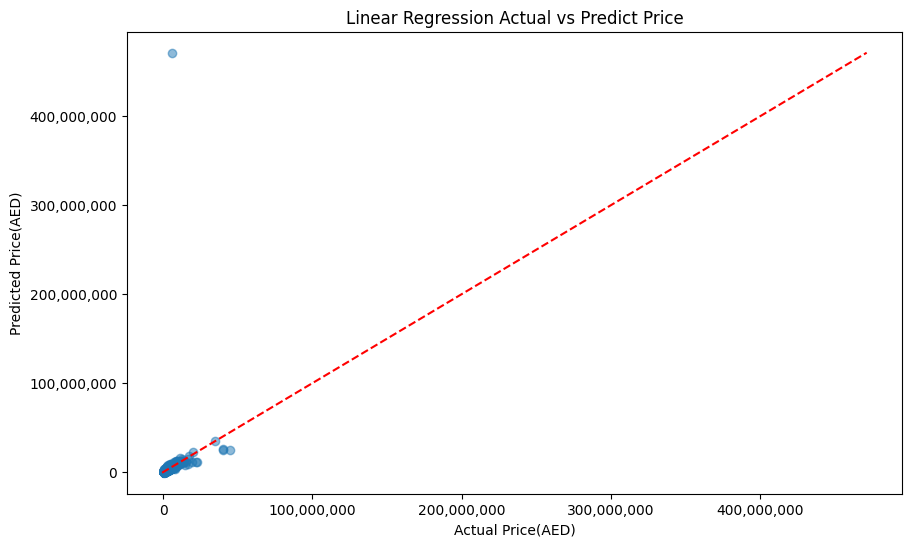

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.xlabel("Actual Price(AED)")
plt.ylabel("Predicted Price(AED)")
plt.title("Linear Regression Actual vs Predict Price")

min_val = min(y_test.min(),y_pred.min())
max_val = max(y_test.max(),y_pred.max())
plt.plot([min_val,max_val],[min_val,max_val],'r--')

# Force AED formatting
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

After training and evaluating the baseline Model(Linear Regression), it is performing very poorly after seeing the r2,MSE,RMSE and MAE. It shows that there the relationship between the features and prices are non-linear along with that many features are correlated(multicollinearity).

**Hence Linear Regression is not great as a final model but fit as a baseline one**.

The next model to test on is the **Random Forest**. The later is an ensemble machine learning model that takes in many decision trees during the training period. It delivers high level of accuracy across diverse datas and problem types. It creates a natural protection from overfitting. (Snowflake,2025).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,root_mean_squared_error, mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=None,
    min_samples_split=2
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest Regression ===")
print("R² Score:", r2_score(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", root_mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

=== Random Forest Regression ===
R² Score: 0.7996575121213316
MSE: 1901262759347.4812
RMSE: 1378862.8500860704
MAE: 307954.6396746867


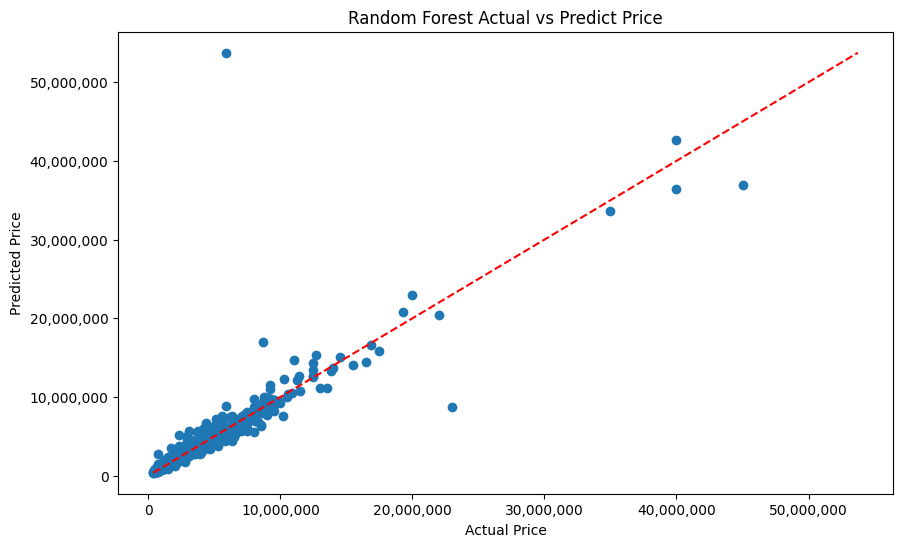

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Actual vs Predict Price")
min_val = min(y_test.min(),y_pred_rf.min())
max_val = max(y_test.max(),y_pred_rf.max())
plt.plot([min_val,max_val],[min_val,max_val],'r--')

# Force AED formatting
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

After performing the Random forest on the dataset, this model is our **Improved** one because it is suited for real estate datasets in which they are able to capture non linear relationships. Other factors like robustness and handling of outliers makes it the best model to use.

The R2,MSE,RMSE AND MAE is performing much better than compared to Linear Regression and in the scatterplot, the data points are almost fitting well into the line. the R2 in Random forest is 0.80 because it handles complex,non-linear and high categorical features effectively.

**Hyperparameters chosen to make the model robust were**:

n_estimators = more the trees, more chances of the model performing well.

random_state = making the output model replicable. The model will always produce the same result whenever the value changes.

min_sample_split = The minimum amount of leafs needed to split the code.

(Donges, 2024)

The baseline model was switched to an improved because the former model performed poorly. R2 score of -13 showed that the dataset robustness and complexity did not suit the baseline model. If new data was fed in, it would had predicted poorly. Hence an improved version(Random Forest) was used because of its performance in complex dataset. the R2 score 0.80 shows that this performance is strong in real estate pricing despite a 10-12% error.

# 7.Validation and Evaluation

The dataset was validated in such a way that it was splitted into Test and Train data(In the Cleaning and Pre-processing stage). After splitting the data, 2 models were used, the Linear Regression(Baseline) and Random Forest(Improved).

The 2 diagnostics used in this dataset is **residual plot** and **Actual vs Predicted Scatter Plot**(Already performed in the Modelling stage).

Residual plot is a graphical representation of residuals also known as errors in linear regression. It is the difference between the real values and predicted values. It simple shows how far off are the predictions from the dataset.(Halder, 2023).

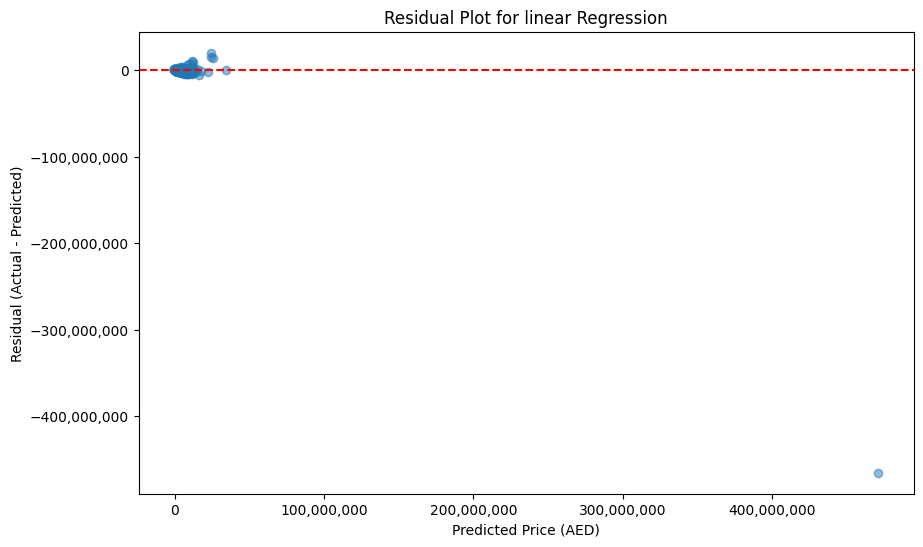

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred,residuals,alpha=0.5)
plt.axhline(0,color='red',linestyle="--")

plt.xlabel("Predicted Price (AED)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot for linear Regression")

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()


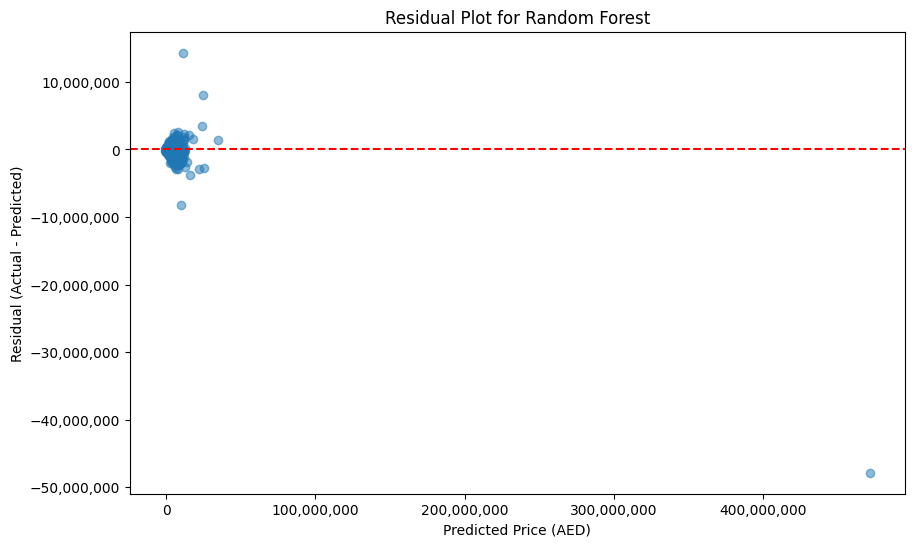

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(10,6))
plt.scatter(y_pred,residuals,alpha=0.5)
plt.axhline(0,color='red',linestyle="--")

plt.xlabel("Predicted Price (AED)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot for Random Forest")

plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()

The two plots repersent the residual graph of Linear Regression and Random Forest. In the Linear Regression, all the points are tightly clustered around 0 but its misleading because the models fails to capture non-linearity of the data. This is shown by the large outlier with a residual exceeding more than 400 million, highlighting the models inability to hand exteme values.

On the other hand, Random Forest data points are distributed below and above zero showing a more random pattern and indicating a better overall fit.

Even though, both the models have the same extreme outlier, The Random Forest manages the data effectively, confirming that its the most superior for task prediction.

# 8. Conclusion

Overall, this project developed a predictive model for a real estate dataset of Dubai properties by using a full data science/Machine learning workflow of data cleaning,data exploration,data visualization,modelling and evaluating.

The main finding was that, Linear Regression being the baseline model performed poorly as it was not able to capture non-linear relationship present in property features. The Random Forest was the improved model as it performed much better than the baseline model by achieving a satisfactory R2 score and lower metrics along with stable and random residual behaviour in the residual plot.

During the residual plot, both the models were effected by the same outlier, with a residual exceeding more than 400 million AED. The limitation in the dataset was skewed distribution, other important features like building age and time constraint of only using 2 models.

If there was more time available, the project could be improved with the help of deeper hyperparameters, advanced models like XGBoost, and applying robust outlier handling techniques. Additional features and performing cross validation would had improved the models performance.

Despite all these limitations, for a dataset like this, a Random Forest performs much better than a simple linear regression when it comes to complex datasets like Real Estate.

# 9. References



1.   Saleem, A. (2024) 🏙 Dubai Real Estate Sales Insights: UAE 🇦🇪 🏠, Kaggle. Available at: https://www.kaggle.com/datasets/azharsaleem/dubai-real-estate-sales-insights (Accessed: 02 April 2026).

2.   Rogers, J. and Jonker, A. (2026) What is data cleaning?, IBM. Available at: https://www.ibm.com/think/topics/data-cleaning (Accessed: 02 April 2026).

2.   Singh, A. (2024) Feature scaling in Machine Learning: What is it?, Feature Scaling In Machine Learning. Available at: https://www.appliedaicourse.com/blog/feature-scaling-in-machine-learning/ (Accessed: 02 April 2026).

2.   DelSole, M. (2018) What is one hot encoding and how to do it | by Michael Delsole | medium, What is One Hot Encoding and How to Do It. Available at: https://medium.com/@michaeldelsole/what-is-one-hot-encoding-and-how-to-do-it-f0ae272f1179 (Accessed: 02 April 2026).

1.   Galarnyk, M. (2025) Train test split: What it means and how to use it, Train Test Split: What It Means and How to Use It. Available at: https://builtin.com/data-science/train-test-split (Accessed: 02 April 2026).

2.   Geeks, G. (2025) Feature selection techniques in machine learning, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/feature-selection-techniques-in-machine-learning/ (Accessed: 02 April 2026).

1.   Coursera (2025) What is exploratory data analysis?, Coursera. Available at: https://www.coursera.org/articles/exploratory-data-analysis (Accessed: 03 April 2026).

1.   Databricks (2025) What is Data Modeling?, Databricks. Available at: https://www.databricks.com/blog/what-is-data-modeling (Accessed: 04 April 2026).
2.   GeeksforGeeks (2026) Linear regression in machine learning, GeeksforGeeks. Available at: https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/ (Accessed: 04 April 2026).

1.   Snowflake (2025) What is Random Forest in machine learning?, The Snowflake Data Cloud - Mobilize Data, Apps, and AI. Available at: https://www.snowflake.com/en/fundamentals/random-forest/ (Accessed: 04 April 2026).

2.   Donges, N. (2024) Random Forest: A complete guide for machine learning, Built In. Available at: https://builtin.com/data-science/random-forest-algorithm (Accessed: 04 April 2026).


1.   Halder, N. (2023) Understanding residual plots in linear regression models: A comprehensive guide with examples | by Nilimesh Halder, Phd | medium, Medium. Available at: https://medium.com/@HalderNilimesh/understanding-residual-plots-in-linear-regression-models-a-comprehensive-guide-with-examples-2fb5a60daf26 (Accessed: 04 April 2026).

1.   Chugh, A. (2020) Mae, MSE, RMSE, coefficient of determination, adjusted R squared — which metric is better? | by Akshita Chugh | analytics vidhya | medium, Medium. Available at: https://medium.com/analytics-vidhya/mae-mse-rmse-coefficient-of-determination-adjusted-r-squared-which-metric-is-better-cd0326a5697e (Accessed: 06 April 2026).

2.   Fernando, J. (2025) R-squared: Definition, calculation, and interpretation, Investopedia. Available at: https://www.investopedia.com/terms/r/r-squared.asp (Accessed: 06 April 2026).




















